# 7.1

Acceptance ratio (sigma^2 = sigma0^2): 0.620990099009901


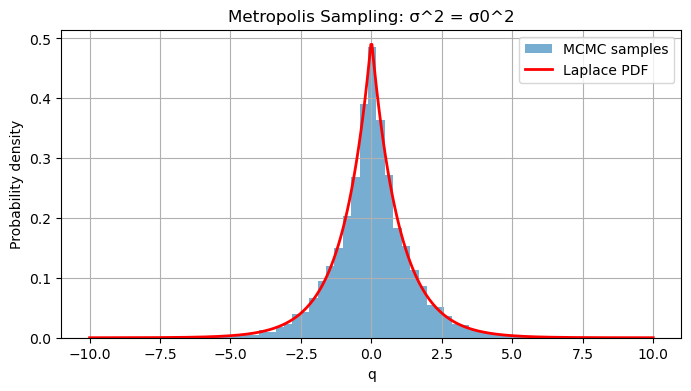

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0) 

mu = 0
b = 1
sigma0_sq = 2 * b**2  # variance of Laplace
M = 10100
burn_in = 100

def p_laplace(q):
    """Laplace PDF."""
    return (1/(2*b)) * np.exp(-np.abs(q - mu)/b)

def metropolis_laplace(M, sigma_sq):
    samples = np.zeros(M)
    q_current = 0.0
    accepted = 0

    for k in range(M):
        q_star = np.random.normal(q_current, np.sqrt(sigma_sq))
        alpha = min(1, p_laplace(q_star) / p_laplace(q_current))
        if np.random.rand() < alpha:
            q_current = q_star
            accepted += 1
        samples[k] = q_current

    return samples[burn_in:], accepted / M  

# -----------------------------
samples1, acc1 = metropolis_laplace(M, sigma0_sq)
print("Acceptance ratio (sigma^2 = sigma0^2):", acc1)

# Plot histogram
q_grid = np.linspace(-10, 10, 500)
plt.figure(figsize=(8,4))
plt.hist(samples1, bins=50, density=True, alpha=0.6, label='MCMC samples')
plt.plot(q_grid, p_laplace(q_grid), 'r-', lw=2, label='Laplace PDF')
plt.xlabel('q')
plt.ylabel('Probability density')
plt.title('Metropolis Sampling: σ^2 = σ0^2')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def check_pdf(samples, bins=100, tol=0.05):
    hist, edges = np.histogram(samples, bins=bins, density=True)
    bin_width = edges[1] - edges[0]
    integral = np.sum(hist * bin_width)
    is_pdf = np.abs(integral - 1.0) < tol
    return integral, is_pdf
integral, is_pdf = check_pdf(samples1, bins=50)
print(f"Numerical integral of histogram = {integral:.4f}, valid PDF? {is_pdf}")


Numerical integral of histogram = 1.0000, is valid PDF? True


The acceptance ratio is approximately $0.621$. 

# 7.2

Acceptance ratio (sigma^2 = sigma0^2): 0.9489108910891089


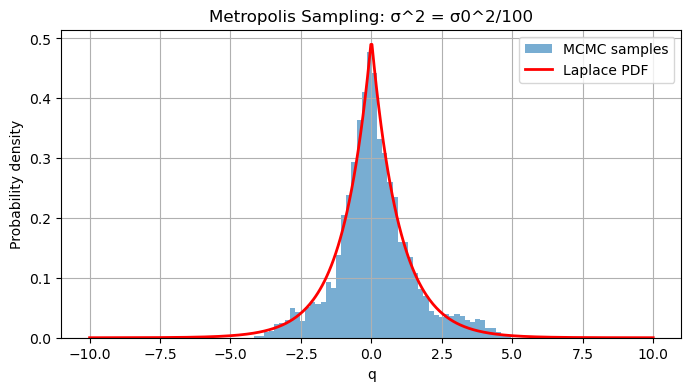

In [9]:

samples2, acc1 = metropolis_laplace(M, sigma0_sq/100)
print("Acceptance ratio (sigma^2 = sigma0^2):", acc1)

# Plot histogram
q_grid = np.linspace(-10, 10, 500)
plt.figure(figsize=(8,4))
plt.hist(samples2, bins=50, density=True, alpha=0.6, label='MCMC samples')
plt.plot(q_grid, p_laplace(q_grid), 'r-', lw=2, label='Laplace PDF')
plt.xlabel('q')
plt.ylabel('Probability density')
plt.title('Metropolis Sampling: σ^2 = σ0^2/100')
plt.legend()
plt.grid(True)
plt.show()


# 7.3

Acceptance ratio (sigma^2 = sigma0^2): 0.10574257425742574


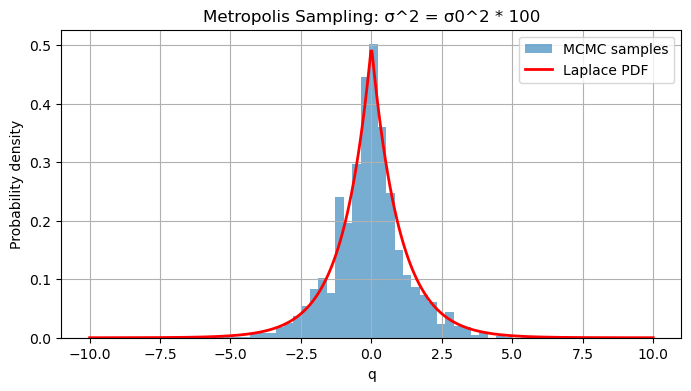

In [11]:

samples3, acc1 = metropolis_laplace(M, sigma0_sq*100)
print("Acceptance ratio (sigma^2 = sigma0^2):", acc1)

# Plot histogram
q_grid = np.linspace(-10, 10, 500)
plt.figure(figsize=(8,4))
plt.hist(samples3, bins=50, density=True, alpha=0.6, label='MCMC samples')
plt.plot(q_grid, p_laplace(q_grid), 'r-', lw=2, label='Laplace PDF')
plt.xlabel('q')
plt.ylabel('Probability density')
plt.title('Metropolis Sampling: σ^2 = σ0^2 * 100')
plt.legend()
plt.grid(True)
plt.show()


The proposal variance $\sigma^2$ has a significant effect on both the histogram of samples and the acceptance ratio in the Metropolis algorithm. When $\sigma^2 = \sigma_0^2/100$, the proposal steps are very small, so most proposed moves are accepted, resulting in an acceptance ratio close to 1. However, the chain explores the state space very slowly, leading to high autocorrelation and a histogram that may converge slowly to the true Laplace distribution (slow exploration). When $\sigma^2 = \sigma_0^2$, the proposal scale is well matched to the target distribution, producing a moderate acceptance ratio (0.621) and good mixing. In this case, the histogram closely matches the Laplace PDF. When $\sigma^2 = 100\sigma_0^2$, the proposal steps are very large, so most proposed moves land in low-density regions and are rejected. This results in a very low acceptance ratio and a chain that becomes “sticky,” leading to poor exploration and a histogram that does not accurately approximate the target distribution.
The histogram variance is, thus, much smaller when the variance of the proposal distribution is small (as few samples are accepted).
These observations are more clearly seen in 7.5, at a smaller number of sample $M$.

# 7.5

The number of samples $M$ and the proposal variance $\sigma^2$ both strongly influence the quality of the resulting approximation to the Laplace distribution. Increasing $M$ improves agreement with the true distribution by reducing Monte Carlo error and allowing the chain more time to explore the state space. However, if $\sigma^2$ is poorly chosen, we have inefficient sampling. If $\sigma^2$ is too small, the chain mixes slowly and requires a very large $M$ to achieve good coverage. If $\sigma^2$ is too large, the chain experiences frequent rejections and remains stuck for long periods, also requiring a much larger $M$ to approximate the target distribution well. Overall, good agreement with the Laplace distribution is achieved when $\sigma^2$ is tuned to produce a moderate acceptance ratio and $M$ is large to ensure adequate mixing and convergence. Note that increasing $M$ values in turn increases the computational cost of the algorithm.

M = 2000, sigma^2 = 0.020, acceptance ratio = 0.947


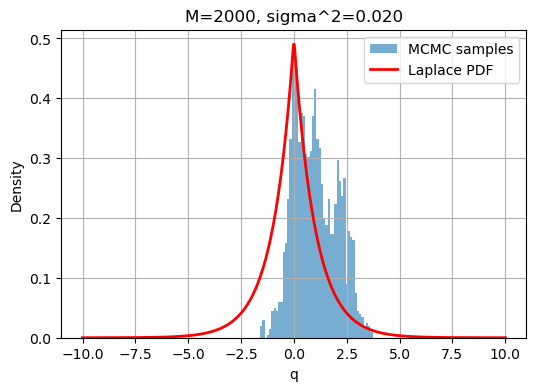

M = 2000, sigma^2 = 2.000, acceptance ratio = 0.627


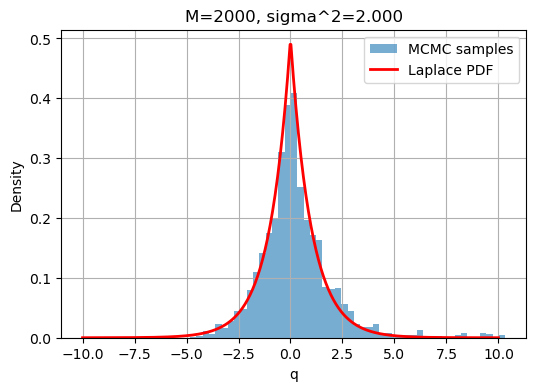

M = 2000, sigma^2 = 200.000, acceptance ratio = 0.103


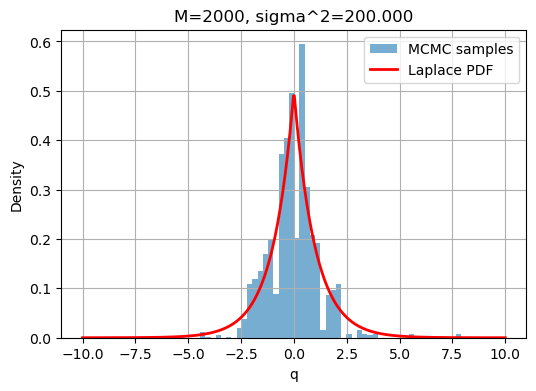

M = 10000, sigma^2 = 0.020, acceptance ratio = 0.944


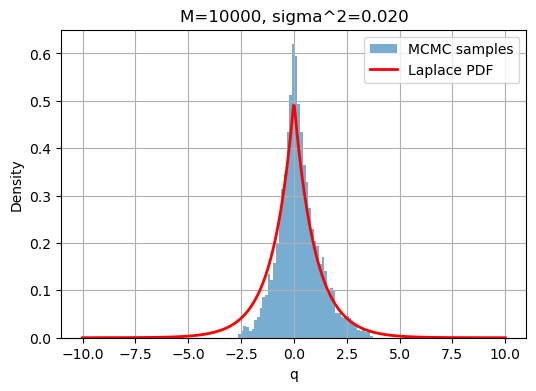

M = 10000, sigma^2 = 2.000, acceptance ratio = 0.623


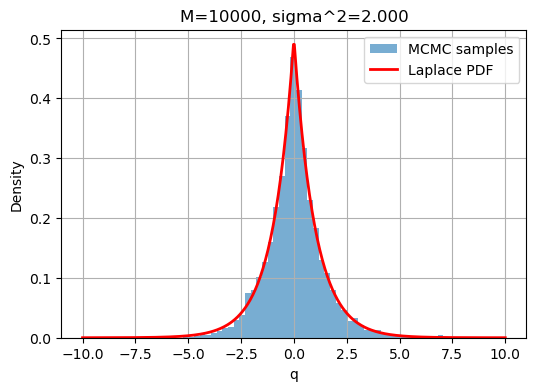

M = 10000, sigma^2 = 200.000, acceptance ratio = 0.110


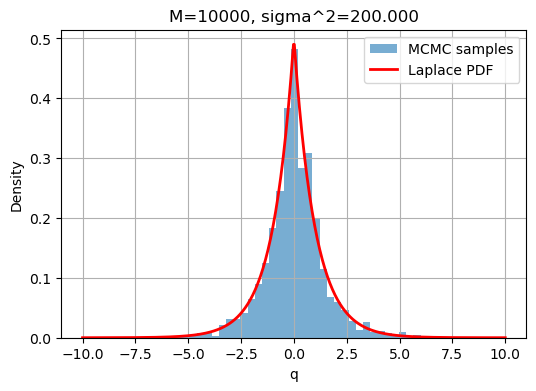

M = 50000, sigma^2 = 0.020, acceptance ratio = 0.946


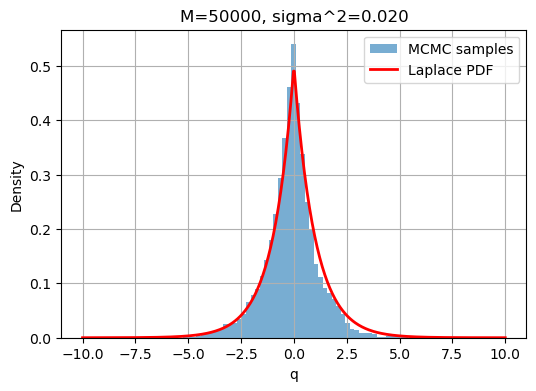

M = 50000, sigma^2 = 2.000, acceptance ratio = 0.612


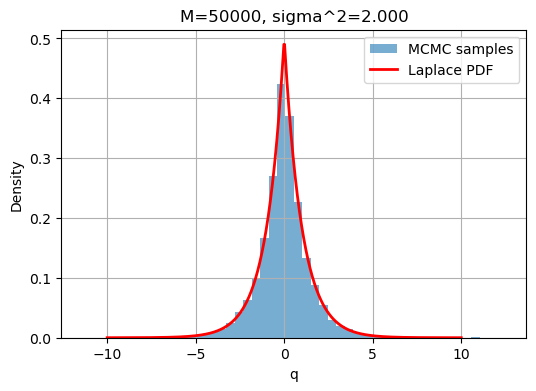

M = 50000, sigma^2 = 200.000, acceptance ratio = 0.107


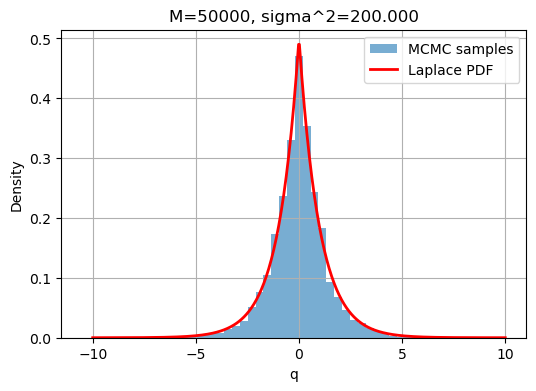

In [12]:
M_values = [2000, 10000, 50000]
sigma_values = [sigma0_sq/100, sigma0_sq, 100*sigma0_sq]

for M in M_values:
    for sigma_sq in sigma_values:
        samples, acc_ratio = metropolis_laplace(M, sigma_sq)

        print(f"M = {M}, sigma^2 = {sigma_sq:.3f}, acceptance ratio = {acc_ratio:.3f}")

        # Plot
        q_grid = np.linspace(-10, 10, 500)

        plt.figure(figsize=(6,4))
        plt.hist(samples, bins=50, density=True, alpha=0.6, label="MCMC samples")
        plt.plot(q_grid, p_laplace(q_grid), 'r-', lw=2, label="Laplace PDF")
        plt.title(f"M={M}, sigma^2={sigma_sq:.3f}")
        plt.xlabel("q")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)
        plt.show()